# Transformer — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

The assembly: attention (13) + MLP (10) + softmax head (11), glued by residuals (the belt reborn) and LayerNorm (stay-awake medicine as a layer). By Block 8 you will have trained a complete language model — one that learns arithmetic because arithmetic was the only way to predict.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

np.random.seed(114)

## Block 2 — A language whose grammar is arithmetic *(README §1)*

The corpus: 8,000 problems as raw text, `"47+05=052;"`. Nobody will tell the model that 0–9 are numbers or that `+` adds — the only signal is next-token loss. And we can compute, IN ADVANCE, where that loss must plateau: 3 of the 9 predicted characters (the problem's own random digits) are unpredictable — an irreducible floor of 3·ln(10)/9.

In [2]:
VOCAB = list("0123456789+=;")
STOI = {c: i for i, c in enumerate(VOCAB)}
train_df = pd.read_csv("data/addition_train.csv")
test_df = pd.read_csv("data/addition_test.csv")
Xtr = np.array([[STOI[c] for c in s] for s in train_df.text])
Xte = np.array([[STOI[c] for c in s] for s in test_df.text])
T, V = Xtr.shape[1], len(VOCAB)
print(f"{len(Xtr)} train / {len(Xte)} held-out problems | T={T}, vocab={V}")
print(f"example: {train_df.text.iloc[0]!r}")
floor = 3*np.log(10)/(T-1)
print(f"\ntheoretical loss floor: 3 unpredictable digits x ln(10), over {T-1} predictions = {floor:.3f}")
print("Every position predicts its NEXT character: one sequence = 9 training examples at once.")

8000 train / 2000 held-out problems | T=10, vocab=13
example: '09+61=070;'

theoretical loss floor: 3 unpredictable digits x ln(10), over 9 predictions = 0.768
Every position predicts its NEXT character: one sequence = 9 training examples at once.


## Block 3 — LayerNorm: the lesson's one new derivative *(README §3.2)*

After many residual additions the stream's scale drifts; drifted scale = saturated bends (lesson 10) and miscalibrated attention scores (lesson 13's √d problem at depth). LayerNorm resets each position's vector to mean 0, var 1 at every block's doorstep, with a learned gain/shift to restore whatever scale is actually wanted. Its backward pass has three terms — because μ and σ each depend on every coordinate — and it's the last new derivative of the course.

In [3]:
def layernorm(x, g, b, eps=1e-5):
    """README §3.2 — per-position recenter & rescale."""
    mu = x.mean(-1, keepdims=True)
    var = x.var(-1, keepdims=True)
    xh = (x - mu) / np.sqrt(var + eps)
    return g * xh + b, (xh, np.sqrt(var + eps))

def layernorm_back(dout, g, cache):
    """README §3.2 — the compact 3-term form: identity, mean-shift, scale-shift."""
    xh, std = cache
    dxh = dout * g
    dg = (dout * xh).sum(axis=(0, 1))
    db = dout.sum(axis=(0, 1))
    dx = (dxh - dxh.mean(-1, keepdims=True) - xh * (dxh * xh).mean(-1, keepdims=True)) / std
    return dx, dg, db

x_demo = np.random.default_rng(0).normal(3, 7, (2, 4, 8))       # badly scaled on purpose
out, _ = layernorm(x_demo, np.ones(8), np.zeros(8))
print(f"input  per-position mean {x_demo.mean(-1).ravel()[:3].round(2)}, std {x_demo.std(-1).ravel()[:3].round(2)}")
print(f"output per-position mean {out.mean(-1).ravel()[:3].round(2)}, std {out.std(-1).ravel()[:3].round(2)}")
print("Whatever the stream drifts to, every block's doorstep sees mean 0, var 1.")

input  per-position mean [ 5.46 -3.19  4.33], std [3.9  4.81 4.83]
output per-position mean [-0.  0.  0.], std [1. 1. 1.]
Whatever the stream drifts to, every block's doorstep sees mean 0, var 1.


## Block 4 — The causal mask, and the crime it prevents *(README §2.2)*

Position 6's target (`5`) sits in plain sight at position 7. Unmasked attention reads it; training becomes copying. The mask: scores to the future set to −∞ BEFORE softmax (−∞, not 0 — softmax(0) still pays out! README §9, mistake 2).

In [4]:
def softmax(Z):
    Z = Z - Z.max(axis=-1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=-1, keepdims=True)

MASK = np.triu(np.ones((T, T)), k=1) * -1e9

demo_scores = np.zeros((T, T))
A_unmasked = softmax(demo_scores)
A_masked = softmax(demo_scores + MASK)
print(f"uniform scores, position 3's budget on FUTURE positions —")
print(f"  unmasked: {A_unmasked[3, 4:].sum():.0%}   <- most of its budget spent peeking")
print(f"  masked  : {A_masked[3, 4:].sum():.0%}   <- the future does not exist")
print(f"  (and note: masking with 0 instead of -1e9 would leave {softmax(np.where(np.triu(np.ones((T,T)),1)==1, 0.0, demo_scores))[3,4:].sum():.0%} leaking)")

uniform scores, position 3's budget on FUTURE positions —
  unmasked: 60%   <- most of its budget spent peeking
  masked  : 0%   <- the future does not exist
  (and note: masking with 0 instead of -1e9 would leave 60% leaking)


## Block 5 — Multi-head: h parallel lesson-13s on slices *(README §3.1)*

One head = one budget = one lookup per position per layer. Our task needs several at once (track digits AND format). The trick is pure reshaping: split the d=48 vector into 4 slices of 12, run lesson 13's attention independently on each, concatenate, mix with one output matrix.

In [5]:
D, HEADS, LAYERS, FF = 48, 4, 2, 128
DH = D // HEADS

def split_heads(x):
    """(m,T,D) -> (m,H,T,DH): four parallel attention problems."""
    return x.reshape(x.shape[0], T, HEADS, DH).transpose(0, 2, 1, 3)

def merge_heads(x):
    """(m,H,T,DH) -> (m,T,D): concatenate the four answers."""
    return x.transpose(0, 2, 1, 3).reshape(x.shape[0], T, D)

demo = np.arange(2*T*D).reshape(2, T, D).astype(float)
back = merge_heads(split_heads(demo))
print(f"split -> merge is lossless: max |difference| = {np.abs(demo - back).max():.0f}")
print(f"each of {HEADS} heads runs lesson 13's attention on a {DH}-dim slice — same total cost as one full-width head, {HEADS}x the lookups")

split -> merge is lossless: max |difference| = 0
each of 4 heads runs lesson 13's attention on a 12-dim slice — same total cost as one full-width head, 4x the lookups


## Block 6 — The block: two humble '+' signs *(README §3.1 + §3.3)*

normalize → attend → ADD; normalize → MLP → ADD. The additions are residuals: out = x + f(x), so ∂out/∂x = I + ∂f/∂x — an identity path with no Jacobian products to vanish. Lesson 12's belt with f nailed to 1. Measured below at init: a plain 16-layer stack starves its bottom layers; the residual stack delivers gradient intact.

In [6]:
rs = np.random.default_rng(0)
def highway_experiment(n_layers, residual):
    x = rs.normal(0, 1, (64, D))
    Ws = [np.random.default_rng(i).normal(0, 0.15, (D, D)) for i in range(n_layers)]
    acts = [x]
    for Wl in Ws:
        h = np.maximum(0, acts[-1] @ Wl)
        acts.append(acts[-1] + h if residual else h)
    d = np.ones_like(acts[-1]) / acts[-1].size
    norms = []
    for i in range(n_layers - 1, -1, -1):
        pre = acts[i] @ Ws[i]
        dxb = (d * (pre > 0)) @ Ws[i].T
        d = (d + dxb) if residual else dxb            # <- README §3.3: the humble +
        norms.append(np.linalg.norm(d))
    return norms[-1]

g_plain = highway_experiment(16, residual=False)
g_res = highway_experiment(16, residual=True)
print(f"gradient reaching layer 1 of a 16-layer stack at init —")
print(f"  plain stack   : {g_plain:.2e}")
print(f"  residual stack: {g_res:.2e}   ({g_res/g_plain:.0f}x more)")
print("The line `dX = dX + dBranch` in Block 7 is this experiment, productionized —")
print("the humblest line in the file, holding up the deepest models on earth.")

gradient reaching layer 1 of a 16-layer stack at init —
  plain stack   : 5.74e-04
  residual stack: 1.22e+01   (21319x more)
The line `dX = dX + dBranch` in Block 7 is this experiment, productionized —
the humblest line in the file, holding up the deepest models on earth.


## Block 7 — The full model, forward and backward, checked three ways *(README §3.1–3.3)*

Everything assembled. The backward pass contains ZERO new derivations beyond Block 3's LayerNorm — every other line is lesson 13's attention gradients, lesson 10's MLP gradients, lesson 11's softmax head, and the residual's `+`. Numerical checks on three different parameter species (attention weight, LN gain, FFN weight) certify the whole machine.

In [7]:
def init_model(seed=0):
    rs = np.random.default_rng(seed)
    def W(*s): return rs.normal(0, 0.15, s)
    P = {"E": W(V, D), "Pos": W(T, D), "Wout": W(D, V), "gF": np.ones(D), "bF": np.zeros(D)}
    for l in range(LAYERS):
        P.update({f"g1_{l}": np.ones(D), f"b1_{l}": np.zeros(D),
                  f"Wq_{l}": W(D, D), f"Wk_{l}": W(D, D), f"Wv_{l}": W(D, D), f"Wo_{l}": W(D, D),
                  f"g2_{l}": np.ones(D), f"b2_{l}": np.zeros(D),
                  f"W1_{l}": W(D, FF), f"c1_{l}": np.zeros(FF),
                  f"W2_{l}": W(FF, D), f"c2_{l}": np.zeros(D)})
    return P

def forward(P, tok, use_mask=True):
    X = P["E"][tok] + P["Pos"][None]
    caches = []
    for l in range(LAYERS):
        A_in, lc1 = layernorm(X, P[f"g1_{l}"], P[f"b1_{l}"])          # pre-LN: highway stays clean
        Q = split_heads(A_in @ P[f"Wq_{l}"]); K = split_heads(A_in @ P[f"Wk_{l}"]); Vv = split_heads(A_in @ P[f"Wv_{l}"])
        S = Q @ K.transpose(0, 1, 3, 2) / np.sqrt(DH)
        if use_mask: S = S + MASK
        A = softmax(S)
        O = merge_heads(A @ Vv) @ P[f"Wo_{l}"]
        X1 = X + O                                                      # residual 1
        F_in, lc2 = layernorm(X1, P[f"g2_{l}"], P[f"b2_{l}"])
        Hf = np.maximum(0, F_in @ P[f"W1_{l}"] + P[f"c1_{l}"])
        X = X1 + (Hf @ P[f"W2_{l}"] + P[f"c2_{l}"])                    # residual 2
        caches.append((A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf))
    Xf, lcF = layernorm(X, P["gF"], P["bF"])
    return Xf @ P["Wout"], (tok, caches, Xf, lcF)

def loss_fn(logits, tok):
    Pr = softmax(logits[:, :-1])
    tgt = tok[:, 1:]
    m = len(tok)
    return -np.mean(np.log(Pr[np.arange(m)[:, None], np.arange(T-1)[None], tgt] + 1e-12))

def backward(P, logits, cache):
    tok, caches, Xf, lcF = cache
    m = len(tok)
    G = {k: np.zeros_like(v) for k, v in P.items()}
    Pr = softmax(logits[:, :-1])
    dlog = np.zeros_like(logits)
    dlog[:, :-1] = (Pr - np.eye(V)[tok[:, 1:]]) / (m * (T - 1))        # the miracle, at every position
    G["Wout"] = np.einsum("mtd,mtv->dv", Xf, dlog)
    dX, G["gF"], G["bF"] = layernorm_back(dlog @ P["Wout"].T, P["gF"], lcF)
    for l in range(LAYERS - 1, -1, -1):
        A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf = caches[l]
        dHf = (dX @ P[f"W2_{l}"].T) * (Hf > 0)                         # lesson 10's gate
        G[f"W2_{l}"] = np.einsum("mtf,mtd->fd", Hf, dX); G[f"c2_{l}"] = dX.sum((0, 1))
        G[f"W1_{l}"] = np.einsum("mtd,mtf->df", F_in, dHf); G[f"c1_{l}"] = dHf.sum((0, 1))
        dX1_ln, G[f"g2_{l}"], G[f"b2_{l}"] = layernorm_back(dHf @ P[f"W1_{l}"].T, P[f"g2_{l}"], lc2)
        dX1 = dX + dX1_ln                                              # README §3.3: the humble +
        Om = merge_heads(A @ Vv)
        G[f"Wo_{l}"] = np.einsum("mtd,mte->de", Om, dX1)
        dOhd = split_heads(dX1 @ P[f"Wo_{l}"].T)
        dA = dOhd @ Vv.transpose(0, 1, 3, 2)
        dVv = A.transpose(0, 1, 3, 2) @ dOhd
        dS = (A * (dA - (dA * A).sum(-1, keepdims=True))) / np.sqrt(DH)  # lesson 13's Jacobian, per head
        dQ = dS @ K; dK = dS.transpose(0, 1, 3, 2) @ Q
        dA_in = merge_heads(dQ) @ P[f"Wq_{l}"].T + merge_heads(dK) @ P[f"Wk_{l}"].T + merge_heads(dVv) @ P[f"Wv_{l}"].T
        G[f"Wq_{l}"] = np.einsum("mtd,mte->de", A_in, merge_heads(dQ))
        G[f"Wk_{l}"] = np.einsum("mtd,mte->de", A_in, merge_heads(dK))
        G[f"Wv_{l}"] = np.einsum("mtd,mte->de", A_in, merge_heads(dVv))
        dX_ln, G[f"g1_{l}"], G[f"b1_{l}"] = layernorm_back(dA_in, P[f"g1_{l}"], lc1)
        dX = dX1 + dX_ln                                               # and again
    G["Pos"] = dX.sum(0)
    np.add.at(G["E"], tok, dX)
    return G

P = init_model(seed=1)
sub = Xtr[:32]
logits, cache = forward(P, sub)
G = backward(P, logits, cache)
eps = 1e-5
for key, idx in [("Wq_0", (3, 5)), ("g1_1", (7,)), ("W1_1", (10, 20))]:
    P[key][idx] += eps; Lu = loss_fn(forward(P, sub)[0], sub)
    P[key][idx] -= 2*eps; Ld = loss_fn(forward(P, sub)[0], sub)
    P[key][idx] += eps
    print(f"grad check {key:6s}: analytic {G[key][idx]:+.7f}   numerical {(Lu-Ld)/(2*eps):+.7f}")
n_params = sum(v.size for v in init_model().values())
print(f"\nall three parameter species agree — the machine is certified. {n_params:,} parameters total.")

grad check Wq_0  : analytic +0.0077986   numerical +0.0077986
grad check g1_1  : analytic -0.0078092   numerical -0.0078092
grad check W1_1  : analytic -0.0030837   numerical -0.0030837

all three parameter species agree — the machine is certified. 45,568 parameters total.


## Block 8 — Train: loss to its floor, skill to 100% *(README §2.4 + §5)*

Watch two curves that tell different stories: loss falls and PLATEAUS (at the floor computed in Block 2 — perfection against irreducible noise), while held-out exact-match climbs to 100%. Then slice by mechanism: carry vs no-carry.

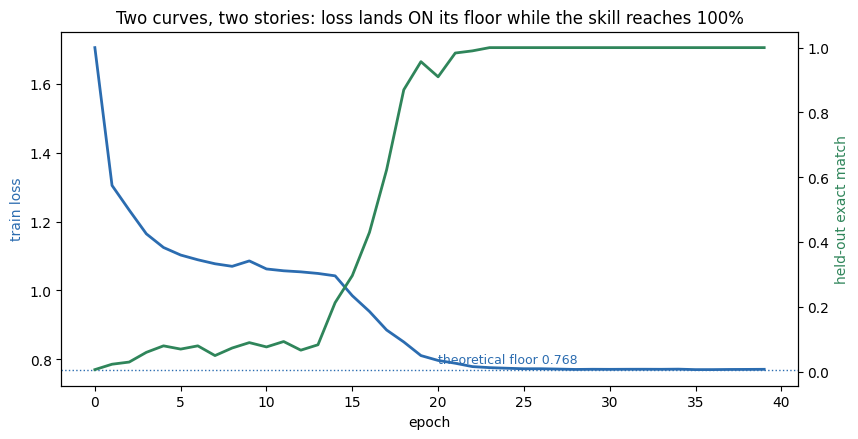

held-out exact match (1,000 unseen problems): 100.0%
  sliced by mechanism — no-carry: 100.0% | carry: 100.0%
final loss 0.7709 vs floor 0.7675: the model is PERFECT and the loss is NONZERO.
Loss is a proxy; the skill is the truth (README §5).


In [8]:
class Adam:
    def __init__(self, P, lr):
        self.m = {k: np.zeros_like(v) for k, v in P.items()}
        self.v = {k: np.zeros_like(v) for k, v in P.items()}
        self.lr, self.t = lr, 0
    def step(self, P, G):
        self.t += 1
        for k in P:
            self.m[k] = 0.9*self.m[k] + 0.1*G[k]
            self.v[k] = 0.999*self.v[k] + 0.001*G[k]**2
            mh = self.m[k]/(1-0.9**self.t); vh = self.v[k]/(1-0.999**self.t)
            P[k] -= self.lr * mh/(np.sqrt(vh)+1e-8)

def exact_match(P, toks, use_mask=True):
    """Prompt 'ab+cd=' -> generate the rest greedily -> grade the full answer, no partial credit."""
    cur = toks.copy(); cur[:, 6:] = STOI[";"]
    for pos in range(6, T):
        lg, _ = forward(P, cur, use_mask)
        cur[:, pos] = lg[:, pos-1].argmax(-1)
    return (cur[:, 6:9] == toks[:, 6:9]).all(1), cur

def train(P, epochs, lr=2e-3, batch=256, seed=0, use_mask=True):
    opt = Adam(P, lr)
    rs = np.random.default_rng(seed)
    hist = {"loss": [], "em": []}
    for ep in range(epochs):
        order = rs.permutation(len(Xtr)); tot = 0.0
        for s_ in range(0, len(Xtr), batch):
            b = order[s_:s_+batch]
            lg, ch = forward(P, Xtr[b], use_mask)
            tot += loss_fn(lg, Xtr[b]) * len(b)
            opt.step(P, backward(P, lg, ch))
        hist["loss"].append(tot/len(Xtr))
        hist["em"].append(exact_match(P, Xte[:300], use_mask)[0].mean())
    return hist

P = init_model(seed=0)
hist = train(P, epochs=40)
ok, gen = exact_match(P, Xte[:1000])
carry = np.array([(int(s[:2]) % 10 + int(s[3:5]) % 10) >= 10 for s in test_df.text[:1000]])

fig, ax = plt.subplots(figsize=(9.5, 4.6)); ax2 = ax.twinx()
ax.plot(hist["loss"], color="#2b6cb0", lw=2)
ax.axhline(floor, color="#2b6cb0", ls=":", lw=1)
ax.text(20, floor+0.02, f"theoretical floor {floor:.3f}", color="#2b6cb0", fontsize=9)
ax2.plot(hist["em"], color="#2f855a", lw=2)
ax.set_xlabel("epoch"); ax.set_ylabel("train loss", color="#2b6cb0"); ax2.set_ylabel("held-out exact match", color="#2f855a")
ax.set_title("Two curves, two stories: loss lands ON its floor while the skill reaches 100%")
plt.show()

print(f"held-out exact match (1,000 unseen problems): {ok.mean():.1%}")
print(f"  sliced by mechanism — no-carry: {ok[~carry].mean():.1%} | carry: {ok[carry].mean():.1%}")
print(f"final loss {hist['loss'][-1]:.4f} vs floor {floor:.4f}: the model is PERFECT and the loss is NONZERO.")
print("Loss is a proxy; the skill is the truth (README §5).")

## Block 9 — Generation: the sampler, the temperature knob, and the crime scene *(README §3.4 + §4)*

(a) Autoregressive completion of unseen prompts. (b) Temperature: crank it and watch the model MISSPELL SUMS — fluent, formatted, wrong: your first hallucination, at 45k parameters. (c) The staged crime: train an UNMASKED model — spectacular loss, useless answers.

In [9]:
def complete(P, prompt, temp=0.0, seed=0):
    rs = np.random.default_rng(seed)
    cur = np.full((1, T), STOI[";"]); cur[0, :len(prompt)] = [STOI[c] for c in prompt]
    for pos in range(len(prompt), T):
        lg, _ = forward(P, cur)
        pr = softmax(lg[0, pos-1] / max(temp, 1e-8)) if temp > 0 else None
        cur[0, pos] = rs.choice(V, p=pr) if temp > 0 else lg[0, pos-1].argmax()
    return "".join(VOCAB[i] for i in cur[0])

print("greedy completions of UNSEEN problems:")
for s in test_df.text[:4]:
    print(f"  prompt {s[:6]!r} -> {complete(P, s[:6])!r}   (truth {s!r})")

# Temperature, MEASURED (an honest surprise inside): sample 60 completions per τ and count errors.
print("\ntemperature vs wrong-answer rate (60 sampled completions of one unseen prompt each):")
rs = np.random.default_rng(7)
wrong_example = None
for temp in [0.5, 1.0, 2.0, 3.0]:
    wrong = 0
    for k in range(60):
        out = complete(P, test_df.text.iloc[0][:6], temp, seed=1000*int(temp*10)+k)
        if out[6:9] != test_df.text.iloc[0][6:9]:
            wrong += 1
            if temp == 3.0 and wrong_example is None: wrong_example = out
    print(f"  τ={temp}: {wrong/60:.0%} wrong")
print(f"\nThe surprise: at τ=0.5 the model is UNSHAKEABLE — its distributions are so peaked")
print(f"(loss at the floor) that mild randomness can't flip a digit. Push harder and errors are")
print(f"manufactured in proportion: e.g. {wrong_example!r} vs truth {test_df.text.iloc[0]!r} —")
print(f"still perfectly formatted, confidently wrong, no abstention (softmax must spend its")
print(f"budget somewhere). Fluency is the format; verify the content (README §5).\n")

P_crime = init_model(seed=2)
hist_crime = train(P_crime, epochs=8, use_mask=False)
ok_crime, _ = exact_match(P_crime, Xte[:300], use_mask=False)
print(f"THE CRIME SCENE — unmasked model after 8 epochs:")
print(f"  train loss {hist_crime['loss'][-1]:.4f}  (below the honest floor {floor:.3f}! it can peek)")
print(f"  held-out exact match: {ok_crime.mean():.1%}")
print("Reading the answer during training taught it nothing about WRITING one (README §2.2).")

greedy completions of UNSEEN problems:
  prompt '21+51=' -> '21+51=072;'   (truth '21+51=072;')
  prompt '34+95=' -> '34+95=129;'   (truth '34+95=129;')
  prompt '89+78=' -> '89+78=167;'   (truth '89+78=167;')
  prompt '38+24=' -> '38+24=062;'   (truth '38+24=062;')

temperature vs wrong-answer rate (60 sampled completions of one unseen prompt each):
  τ=0.5: 0% wrong


  τ=1.0: 3% wrong
  τ=2.0: 20% wrong


  τ=3.0: 63% wrong

The surprise: at τ=0.5 the model is UNSHAKEABLE — its distributions are so peaked
(loss at the floor) that mild randomness can't flip a digit. Push harder and errors are
manufactured in proportion: e.g. '21+51=082;' vs truth '21+51=072;' —
still perfectly formatted, confidently wrong, no abstention (softmax must spend its
budget somewhere). Fluency is the format; verify the content (README §5).



THE CRIME SCENE — unmasked model after 8 epochs:
  train loss 0.0015  (below the honest floor 0.768! it can peek)
  held-out exact match: 0.0%
Reading the answer during training taught it nothing about WRITING one (README §2.2).


## Block 10 — The autoregressive tax, the KV-cache idea, and the door *(README §3.4 + §6)*

Training was parallel across positions; GENERATION is not — each new token needs a full forward pass over everything so far. Measure it, then see the trick every serving stack uses: past positions' K,V never change, so cache them and compute only the new token's row.

In [10]:
prompt_toks = np.array([[STOI[c] for c in test_df.text.iloc[0][:6]] + [STOI[";"]]*4])
t0 = time.time()
for _ in range(20): complete(P, test_df.text.iloc[0][:6])
t_gen = (time.time()-t0)/20
t0 = time.time()
for _ in range(20): forward(P, prompt_toks)
t_fwd = (time.time()-t0)/20
print(f"one training-style forward pass : {t_fwd*1000:.1f} ms  (all positions graded at once)")
print(f"one 4-character generation      : {t_gen*1000:.1f} ms  ({t_gen/t_fwd:.1f}x — a fresh full pass per token)")
print()
print(f"The KV-cache idea: at generation step t, positions 0..t-1's keys and values are IDENTICAL")
print(f"to last step's — recomputing them is pure waste. Cache K,V per layer; each new token")
print(f"computes only its own Q,K,V and one attention row. Cost per token: O(T·d) instead of")
print(f"O(T²·d). Every serving stack on earth does this; the memory it eats is the 'KV cache'")
print(f"you hear about in LLM infrastructure. Nothing mystical — just Block 7's forward,")
print(f"refusing to repeat itself.")
print()
print("THE DOOR: this architecture now owns text. Lesson 15 hands it IMAGES — chop the picture")
print("into patches, call each patch a token, and let lesson 11's beliefs compete with learned")
print("attention. The takeover begins.")

one training-style forward pass : 0.4 ms  (all positions graded at once)
one 4-character generation      : 1.7 ms  (4.7x — a fresh full pass per token)

The KV-cache idea: at generation step t, positions 0..t-1's keys and values are IDENTICAL
to last step's — recomputing them is pure waste. Cache K,V per layer; each new token
computes only its own Q,K,V and one attention row. Cost per token: O(T·d) instead of
O(T²·d). Every serving stack on earth does this; the memory it eats is the 'KV cache'
you hear about in LLM infrastructure. Nothing mystical — just Block 7's forward,
refusing to repeat itself.

THE DOOR: this architecture now owns text. Lesson 15 hands it IMAGES — chop the picture
into patches, call each patch a token, and let lesson 11's beliefs compete with learned
attention. The takeover begins.


---
## What you now own

- The block: normalize → attend → add, normalize → compute → add — and the division of labor (attention moves, MLP computes)
- The two glues, both measured: residuals (∂/∂x = I + …, a toll-free highway; 16-layer experiment) and LayerNorm (its 3-term backward: the course's final new derivative)
- The causal mask as enforced honesty, and the crime scene when it's missing
- A complete NumPy language model: 45,568 parameters, 100% held-out exact-match on arithmetic — the skill precipitating out of prediction
- The loss-floor insight (perfect model, nonzero loss), temperature-manufactured hallucination, and the KV-cache

**Next:** `transformer_with_library.ipynb` — then folder `15-vision-transformers`: the takeover reaches images.